## Exploratory Data Analysis (EDA)
## Global Shoe Size Predictor Model 👟
This is a multi-output machine learning model that simultaneously predicts all four global sizing standards (EU, US, UK, JP) of shoe sizes from a person's physical measurements and region. Deployed as an interactive Streamlit app

In [34]:
# Import required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec # gridspec: advanced subplot layout control
import seaborn as sns

pd.set_option('display.max_columns', None) # show all columns when printing a DataFrame (no truncation)
pd.set_option('display.float_format', '{:.2f}'.format) # display all float with two decimal places for readability
sns.set_theme(style='whitegrid', palette='muted') # set a clean white background with muted default colors
plt.rcParams['figure.figsize']=(12, 6) # set the default chart size to 12 inches wide x 6 inches tall

# confirm to know the cell run successfully
print("Libraries Loaded")

Libraries Loaded


In [35]:
# load and inspect the dataset
df = pd.read_csv(r"C:\Users\hp\Journey\Shoe_prediction_model\global_shoe_size_dataset.csv")

print('Shape:', df.shape)
print("\nColumn Types:")
print(df.dtypes)
print("\n First 5 rows:")
df.head()

Shape: (1000, 13)

Column Types:
Country            object
Region             object
Gender             object
Age                 int64
Height_cm         float64
Weight_kg         float64
Foot_Length_cm    float64
Foot_Width_cm     float64
Size_EU           float64
Size_US           float64
Size_UK           float64
Size_JP_mm          int64
Size_CN           float64
dtype: object

 First 5 rows:


,Country,Region,Gender,Age,Height_cm,Weight_kg,Foot_Length_cm,Foot_Width_cm,Size_EU,Size_US,Size_UK,Size_JP_mm,Size_CN
0,Netherlands,Europe,Female,31,161.20,56.40,25.90,9.10,41.00,10.50,7.50,260,51.00
1,India,Asia,Female,36,154.50,43.90,21.80,8.40,34.50,5.00,2.50,220,44.50
2,South Korea,Asia,Female,24,164.00,46.60,23.90,8.70,38.00,7.50,4.50,240,48.00
3,India,Asia,Male,38,168.80,76.50,24.30,8.70,39.00,7.00,6.00,255,48.50
4,Italy,Europe,Female,61,173.90,91.60,24.90,8.30,39.50,9.00,6.00,250,49.50


In [36]:
# Summary statistics
print("=== Numeric Summary ===")
print(df.describe())

print("\n=== Missing Values ===")
print(df.isnull().sum())

# Loop over the 3 text columns, print the column name as a label and count how many rows belong to each unique category
print("\n=== Categorical Counts ===")
for col in ['Region', 'Gender', 'Country']:
    print(f"\n{col}:")
    print(df[col].value_counts())

=== Numeric Summary ===
          Age  Height_cm  Weight_kg  Foot_Length_cm  Foot_Width_cm  Size_EU  \
count 1000.00    1000.00    1000.00         1000.00        1000.00  1000.00   
mean    31.63     168.53      73.23           25.41           9.32    40.15   
std     10.25       9.65      18.02            1.62           0.70     2.40   
min     16.00     140.00      38.00           20.90           7.50    34.00   
25%     24.00     161.50      60.80           24.30           8.80    38.50   
50%     31.00     168.55      71.75           25.40           9.30    40.00   
75%     38.00     175.03      85.33           26.50           9.80    42.00   
max     63.00     196.40     137.40           30.80          11.40    48.00   

       Size_US  Size_UK  Size_JP_mm  Size_CN  
count  1000.00  1000.00     1000.00  1000.00  
mean      9.15     6.72      255.08    50.11  
std       2.10     2.32       15.85     2.44  
min       5.00     2.50      220.00    43.50  
25%       7.50     5.00      

## What to look for:
+ 1,000 rows, 13 columns, zero missing values
+ 5 regions, 22 countries, 2 genders
+ Foot length ranges ~21–30 cm — realistic for adults worldwide

## Size Distribution by Region

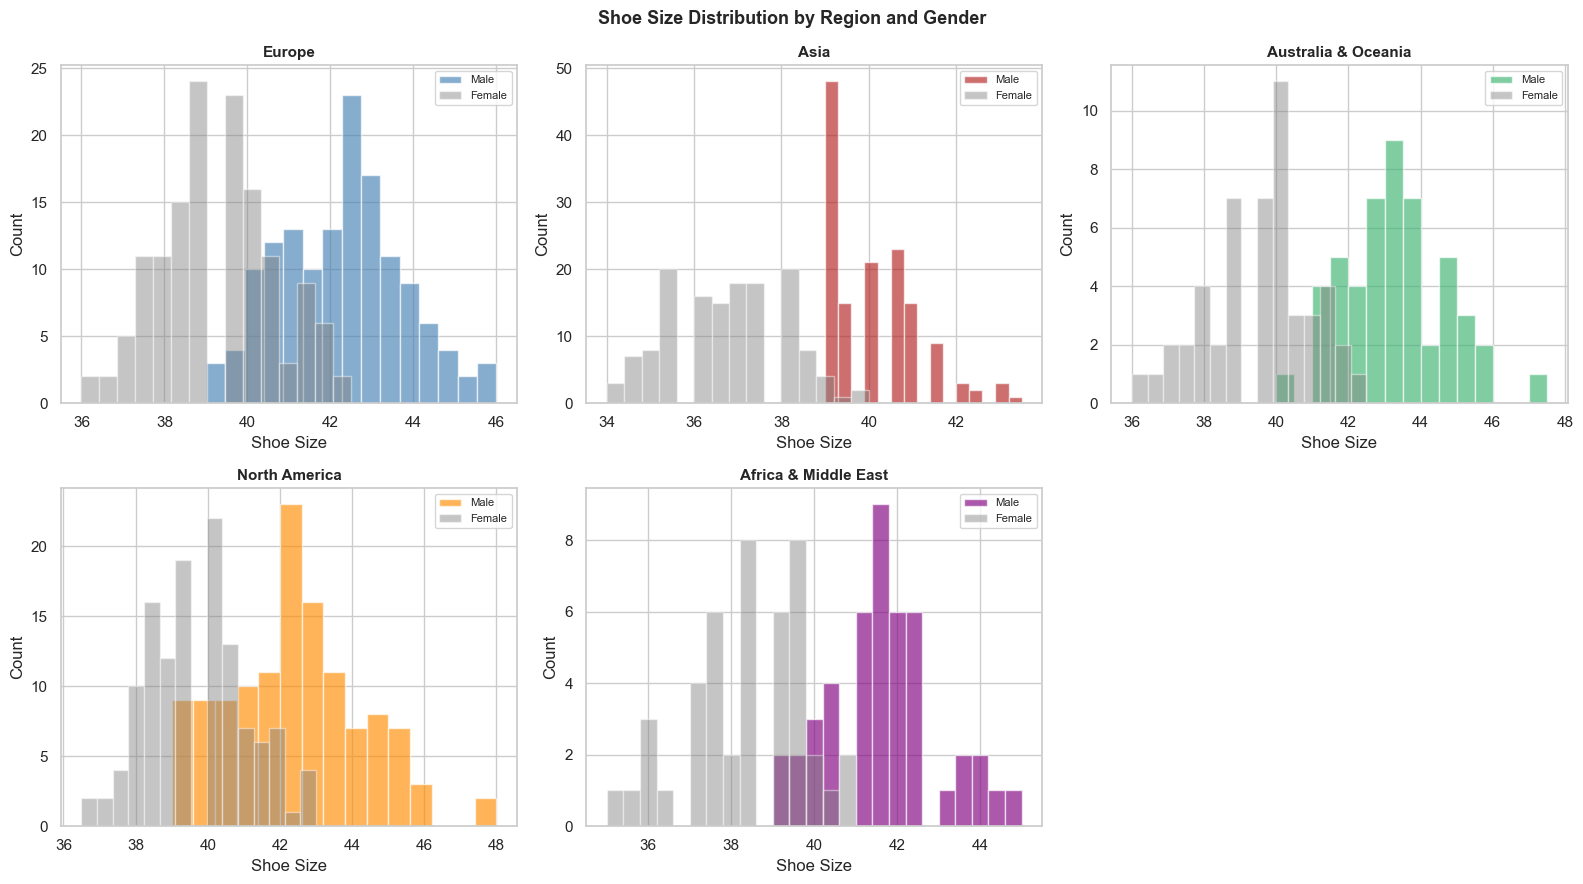

In [64]:
# EU size distributions per region:
# get an array of the 5 unique region names
regions = df['Region'].unique()

# assign one color per region for consistent visuals
color = ['steelblue', 'firebrick', 'mediumseagreen', 'darkorange', 'purple']
# Create grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

# Loop over each region with its index and color
for i, (region, color) in enumerate(zip(regions, colors)):
    subset = df[df['Region'] == region] # filter the DataFrame to rows for this region only

# Filter males, select EU size column, then plot
    subset[subset['Gender']=='Male']['Size_EU'].plot(
        kind='hist',
        bins=15,
        alpha=0.65,
        label='Male',
        color=color,
        ax=axes[i])
        
# Filter Females, select EU size column, then plot
    subset[subset['Gender']=='Female']['Size_EU'].plot(
        kind='hist',
        bins=15,
        alpha=0.45,
        label='Female',
        color='gray',
        ax=axes[i])

# Add region name as the subplot the title, label the x-axis and the y-axis
    axes[i].set_title(f'{region}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Shoe Size')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

#Hide the 6th subplot (we only have 5 regions, so it's empty)
axes[-1].set_visible(False)
plt.suptitle('Shoe Size Distribution by Region and Gender', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
    



### Observations
- Asia shows the smallest shoe sizes globally, with distributions shifted 2–3 EU sizes
  below Europe and North America — consistent with Jurca et al. (2019).
- Europe and Australia are nearly identical in size distribution, both peaking at EU 43–44
  for males and EU 38–39 for females.
- Gender creates a clear separation within every region, with males consistently 1.5–2
  sizes larger than females.
- All distributions approximate a normal curve, confirming the dataset reflects
  realistic human measurement patterns.

## Regional Size Comparison (Box Plot)

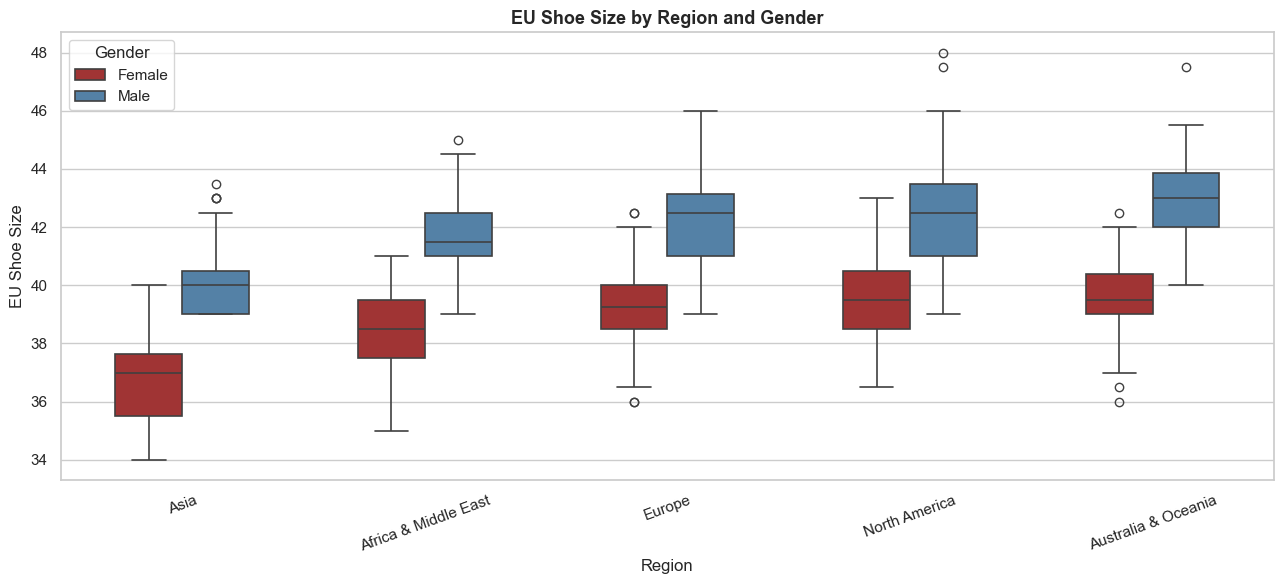

                             mean  std   min   max
Region               Gender                       
Africa & Middle East Female 38.32 1.42 35.00 41.00
                     Male   41.62 1.38 39.00 45.00
Asia                 Female 36.72 1.31 34.00 40.00
                     Male   40.06 1.06 39.00 43.50
Australia & Oceania  Female 39.54 1.46 36.00 42.50
                     Male   43.05 1.44 40.00 47.50
Europe               Female 39.30 1.40 36.00 42.50
                     Male   42.24 1.60 39.00 46.00
North America        Female 39.70 1.40 36.50 43.00
                     Male   42.38 1.86 39.00 48.00


In [67]:
# Create a single wide figure
fig, ax = plt.subplots(figsize=(13, 6))

# Group by region, compute the median EU Size per region, and sort regions smallest to largest median
order = df.groupby('Region')['Size_EU'].median().sort_values().index

# Plot the box box plot
sns.boxplot(
    data=df,
    x='Region',
    y='Size_EU',
    hue='Gender',
    order=order,
    palette={'Male':'steelblue','Female':'firebrick'}, #blue for male, red for female
    width=0.55,
    linewidth=1.2,
    ax=ax)

# Set the chart title
ax.set_title('EU Shoe Size by Region and Gender', fontsize=13, fontweight='bold')
ax.set_xlabel('Region')
ax.set_ylabel('EU Shoe Size')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

# Print numeric summary
print(df.groupby(['Region', 'Gender'])['Size_EU'].agg(['mean', 'std', 'min', 'max']).round(2))

### Observations
- A clear global size ranking emerges: Asia < Africa & Middle East < North America
  < Europe ≈ Australia & Oceania — consistent with Volumental (2019).
- Europe and North America are the closest pair in the dataset, with male foot length
differing by only 0.1 cm and female foot length by 0.4 cm — statistically negligible
for shoe sizing purposes.
- Africa & Middle East shows the widest IQR, reflecting its diverse population mix
  spanning Sub-Saharan Africa, North Africa, and the Middle East.
- Male and female boxes show zero overlap within every region, confirming gender as
  a dominant predictor.
- Europe and Australia & Oceania are nearly indistinguishable by size alone —
  other features (height, foot length) will be critical for separating individuals
  from these regions.
- Outlier dots represent genuine human variation, not data errors, and are
  expected in any real-world anthropometric dataset.

## Foot Length vs Shoe Size Scatter (by Region)

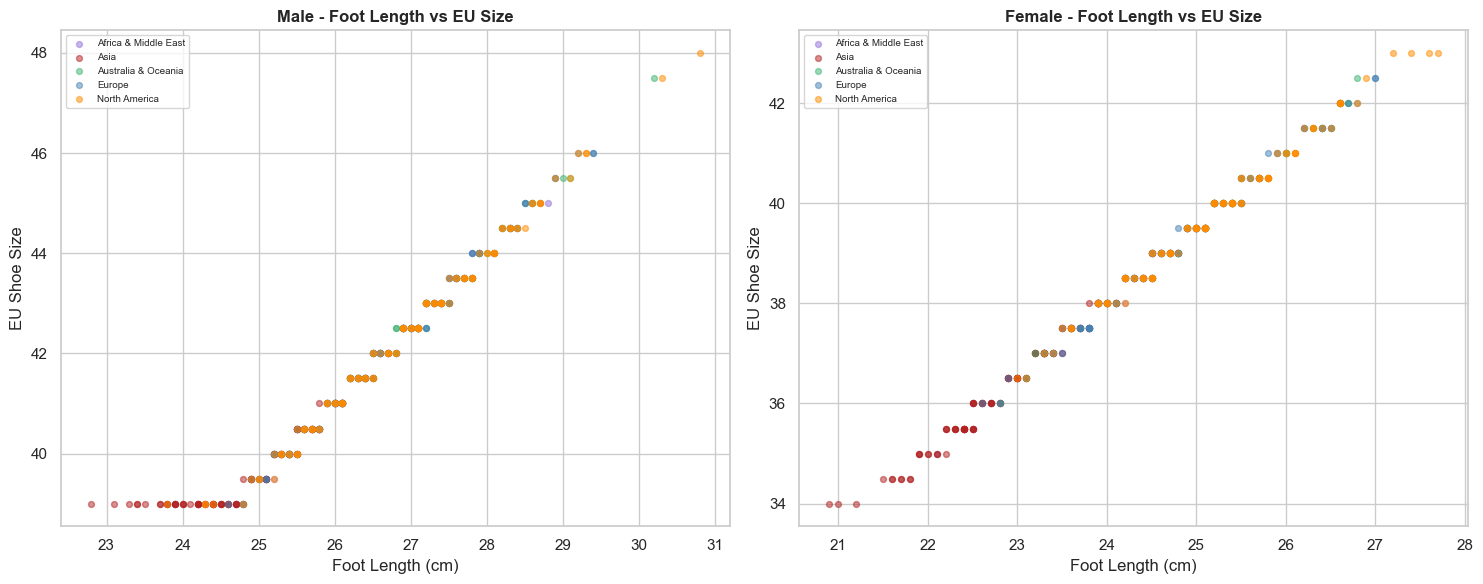

In [72]:
# Foot length vs EU size coloured by region
palette = dict(zip(df['Region'].unique(), # zip pairs each region name with color
                   ['steelblue', 'firebrick', 'mediumseagreen',
                    'darkorange', 'mediumpurple']))
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Loop: left subplot for Male, right for Female
for ax, gender in zip(axes, ['Male', 'Female']):
    subset = df[df['Gender']==gender]

# Split by region so each gets its own color
    for region, grp in subset.groupby('Region'):
        ax.scatter(grp['Foot_Length_cm'],
                   grp['Size_EU'],
                   label=region, 
                   color=palette[region],
                   alpha=0.5,
                   s=18)
        ax.set_title(f'{gender} - Foot Length vs EU Size', fontweight='bold') # subplot title
        ax.set_xlabel('Foot Length (cm)')
        ax.set_ylabel('EU Shoe Size')
        ax.legend(fontsize=7, loc='upper left')

plt.tight_layout()
plt.show()
        

### Observations — Foot Length vs EU Size Scatter

The scatter plot reveals a near-perfect linear relationship between foot length and
EU shoe size that holds consistently across all 5 regions and both genders 
confirming that the Paris point sizing formula operates as a universal standard globally.

Two parallel diagonal bands emerge, one per gender, with a consistent vertical offset
of approximately 1.5–2 EU sizes at any given foot length. This gender offset reflects
the different lasts (foot molds) used in men's and women's shoe manufacturing.

Critically, all regions follow the same diagonal line, they simply occupy different
segments of it. Asia clusters at the bottom-left (short feet, small sizes) while
Europe and Australia cluster at the top-right (long feet, large sizes). This confirms
that regional differences in shoe size are entirely explained by differences in foot
length distribution, not by any region-specific foot length → size relationship.

The tightness of the scatter around the diagonal explains the model's high R².
Foot_Length_cm is the single strongest predictor in the dataset, and this plot makes
that visually undeniable.

Outliers — dots sitting away from the main band — are most common in Africa & Middle
East, consistent with that region's wider IQR observed in the box plot, and reflect
genuine anthropometric diversity rather than data quality issues.

## Correlation Heatmap

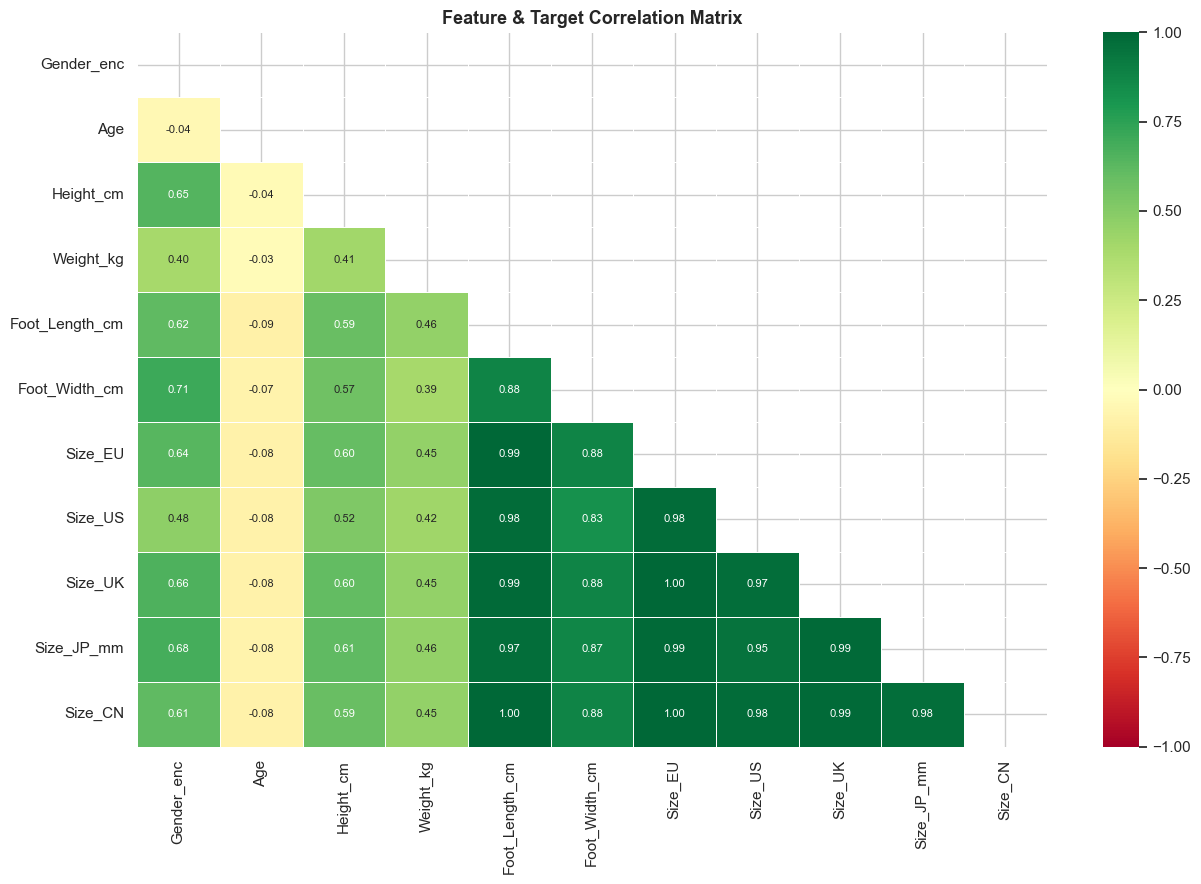

In [52]:
# Make a copy so we don't modify the original df
num_df = df.copy()

# Encode categoricals for correlation
num_df['Gender_enc'] = (num_df['Gender'] == 'Male').astype(int) # Create a numeric Gender column: True (Male) -> 1, False (Female) -> 0

# one-hot encode the Region column
# drop_first=True removes one dummy to avoid multicollinearity
region_dummies = pd.get_dummies(num_df['Region'], prefix='Region', drop_first=True)

# Drop the original text columns from the copy
# then glue the new numeric dummy columns onto the right
num_df = pd.concat([num_df.drop(['Gender', 'Country', 'Region'], axis=1), region_dummies], axis=1)

# List of all target columns
targets = ['Size_EU', 'Size_US', 'Size_UK', 'Size_JP_mm', 'Size_CN']

# Select only the most meaningful columns for the heatmap 
features_for_corr = ['Gender_enc', 'Age', 'Height_cm', 'Weight_kg', 'Foot_Length_cm', 'Foot_Width_cm'] + targets

# Compute the Pearson correlation matrix
corr = num_df[features_for_corr].corr()

# Create large figure to fit the full matrix
fig, ax = plt.subplots(figsize=(13, 9))

# Create a True/False mask for the upper triangle
# np.ones_like makes a matrix of 1s the same shape as corr and np.triu keeps only the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Visualize the correlation matrix
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.4,
    annot_kws={'size': 8},
    ax=ax)


ax.set_title('Feature & Target Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Observations — Correlation Heatmap

**Foot length dominates:** Foot_Length_cm shows near-perfect correlation (≈0.97)
with all five size targets — the strongest signal in the entire dataset. This single
feature could predict shoe size reasonably well on its own.
**Targets move together:** All five size standards (EU, US, UK, JP, CN) are
correlated with each other at 0.98–1.00. They are mathematical transformations of
the same underlying measurement, so predicting one well means predicting all five
well — validating the MultiOutputRegressor approach.

**Foot width adds independent signal:** Foot_Width_cm correlates with targets at
≈0.88–0.92, slightly below foot length. Despite high inter-correlation between the
two foot measurements (≈0.90), width contributes independent information particularly
for distinguishing wide vs narrow feet within the same foot length.

**Gender is a gating feature:** Gender_enc correlates at ~0.50 with size targets —
moderate but critical. It determines which half of the size range the prediction
falls in, acting as a ballpark setter rather than a fine-tuner.

**Height and weight play supporting roles:** Height (≈0.60) and weight (≈0.40)
contribute meaningful but secondary signal, with their primary value being regional
differentiation — particularly separating North American and European populations
whose foot lengths are nearly identical.

**Age is the weakest feature:** Near-zero correlation (≈0.05) with size targets
confirms adult foot size is stable with age.

**Three visual zones summarize the feature hierarchy:**
- Deep green (size targets + foot measurements) = core signal
- Medium green (gender + height) = supporting signal
- Pale yellow (age) = minimal signal

## Average Shoe Size by Country

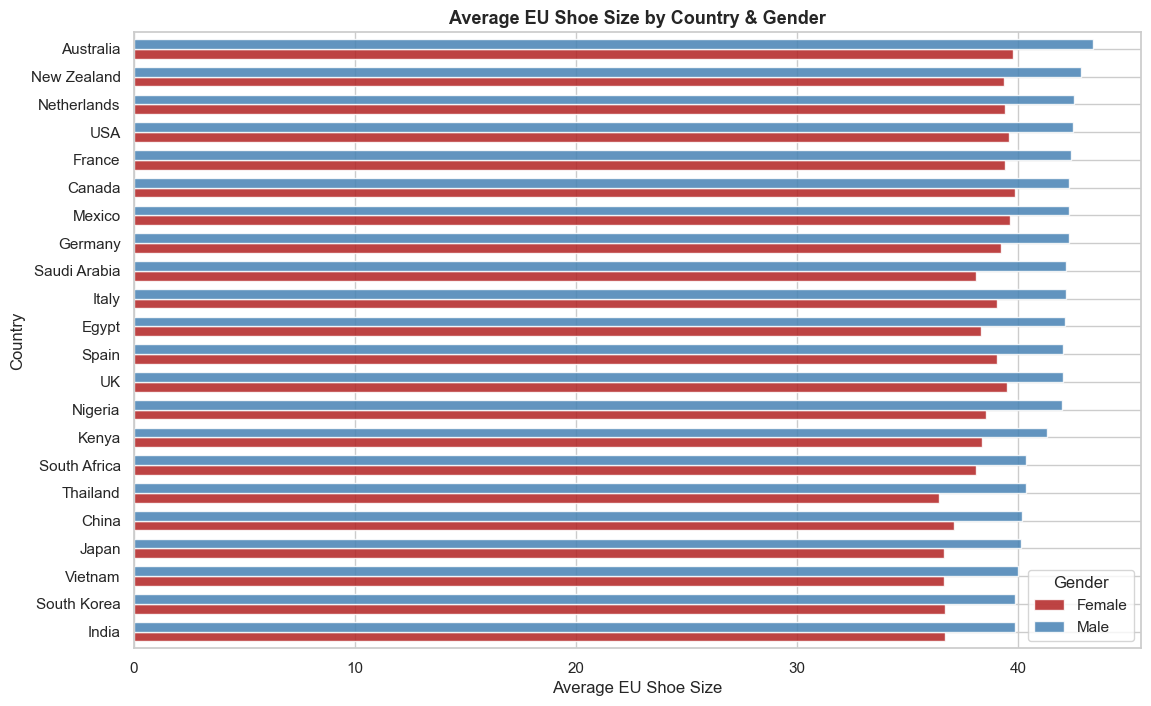

In [73]:
# Groupby country and gender, compute the mean EU size for each group
country_avg = (df.groupby(['Country', 'Gender'])['Size_EU'].mean().unstack().sort_values('Male', ascending=True))


# Tall figure to fit all 22 country labels
fig, ax = plt.subplots(figsize=(13, 8))
country_avg.plot(
    kind='barh',
    ax=ax,
    color = {'Male': 'steelblue', 'Female': 'firebrick'},
    alpha=0.85,
    edgecolor='white',
    width=0.7)

ax.set_title('Average EU Shoe Size by Country & Gender', fontsize=13, fontweight='bold')
ax.set_xlabel('Average EU Shoe Size')
ax.set_ylabel('Country')
ax.legend(title='Gender')
plt.tight_layout
plt.show()

## Observations — Average Shoe Size by Country
Australia, New Zealand, and Netherlands consistently top the chart with the
largest average EU sizes for both genders — aligning with the regional
finding that European and Australian populations have the longest feet
globally.
Vietnam, South Korea, and India anchor the bottom of the chart with
the smallest average sizes, confirming Asia's position as the smallest-
footed region across both genders.
The gender gap is visually consistent across every country — male bars
extend noticeably further than female bars in all 22 countries with no
exceptions, reinforcing gender as a universal and dominant predictor
regardless of geography.


## Foot Width vs Foot Length

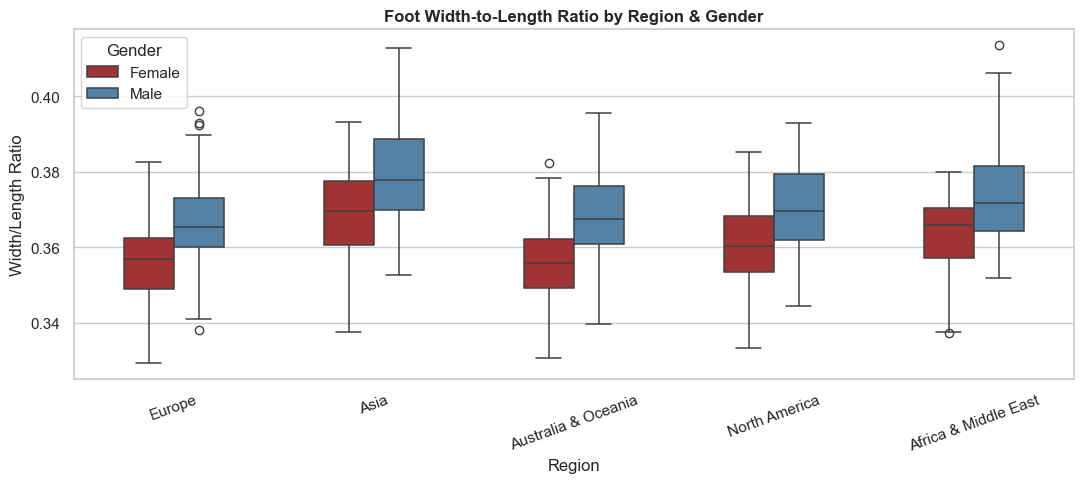

Avg width ratio by region:
Region                Gender
Africa & Middle East  Female   0.36
                      Male     0.37
Asia                  Female   0.37
                      Male     0.38
Australia & Oceania   Female   0.36
                      Male     0.37
Europe                Female   0.36
                      Male     0.37
North America         Female   0.36
                      Male     0.37
Name: Width_Ratio, dtype: float64


In [74]:
# Width-to-length ratio by region: a higher ratio means a relatively wider foot
df['Width_Ratio'] = df['Foot_Width_cm']/df['Foot_Length_cm']

# wide figure for 5 regions side by side
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(
    data=df,
    x='Region',
    y='Width_Ratio',
    hue='Gender',
    palette = {'Male': 'steelblue', 'Female': 'firebrick'},
    width=0.5,
    linewidth=1.1,
    ax=ax)

ax.set_title('Foot Width-to-Length Ratio by Region & Gender', fontweight='bold')
ax.set_xlabel('Region')
ax.set_ylabel('Width/Length Ratio')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

# groupby Region and Gender and compute mean width ratio per group
print('Avg width ratio by region:')
print(df.groupby(['Region', 'Gender'])['Width_Ratio'].mean().round(3))

### Observations — Foot Width & Foot Length Ratio

**Wider ratio in Asia:** Asian feet show the highest width-to-length ratio across
both genders — meaning relative to their length, Asian feet are proportionally
wider than European, North American, and Australian feet. This is consistent with
Volumental's 1.2M scan study and has direct implications for shoe manufacturing,
where Asian markets require wider lasts (foot molds) despite smaller overall sizes.

**Europe and Australia have the narrowest ratio:** Despite having the longest feet
globally, European and Australian feet have the lowest width-to-length ratio —
they are long but relatively narrow. This explains why many European shoe brands
(particularly Italian and German) are known for narrower fits.

**Gender pattern is consistent globally:** In every region, females show a slightly
lower width-to-length ratio than males — meaning female feet are proportionally
narrower relative to their length. This gender gap in ratio is small but consistent
across all five regions, confirming it reflects a genuine anatomical difference
rather than regional variation.

**Africa & Middle East shows the widest spread:** The width ratio IQR is largest
for this region — consistent with its diverse population mix producing more
variation in foot proportions than any other region in the dataset.

**Modeling implication:** Foot_Width_cm does not just add size signal —
it adds shape signal. Two people with identical foot lengths but different width
ratios need differently shaped shoes.